# Dashboard de resultados de evaluación RAG

Este notebook carga los `*_eval.csv` y `*_summary.json` generados por `evaluacion_rag.ipynb` para:
- visualizar métricas por modelo,
- comparar retrieval/generación/robustez,
- revisar manualmente respuestas fallidas según reglas.


In [1]:
!pip install -q -U pandas matplotlib seaborn plotly ipywidgets


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 109.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 137.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 94.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.


In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")
pd.set_option('display.max_colwidth', 160)


In [3]:
# CONFIG
ROOT = Path('/content/drive/MyDrive/NLP_PRACTICA/evaluacion_rag_runs')
ONLY_LATEST_PER_MODEL = True

# Reglas de fallo para revisión manual
JUDGE_FAIL_THRESHOLD = 3.0
FAITHFULNESS_FAIL_THRESHOLD = 0.5
SIM_FAIL_THRESHOLD = 0.45
RETRIEVAL_FAIL_THRESHOLD = 0.0  # hit@k <= 0 => fallo retrieval


In [5]:
# CARGA DE ARCHIVOS
all_eval = sorted(ROOT.glob('**/*_eval.csv'))
all_summary = sorted(ROOT.glob('**/*_summary.json'))

if not all_eval:
    raise FileNotFoundError(f"No encontré *_eval.csv en {ROOT}")

print(f"Eval CSVs encontrados: {len(all_eval)}")
print(f"Summary JSON encontrados: {len(all_summary)}")

if ONLY_LATEST_PER_MODEL:
    latest = {}
    for p in all_eval:
        model = p.parent.name
        latest[model] = max(latest.get(model, p), p)
    eval_files = sorted(latest.values())
else:
    eval_files = all_eval

print("CSVs usados:")
for p in eval_files:
    print(" -", p)


Eval CSVs encontrados: 5
Summary JSON encontrados: 5
CSVs usados:
 - /content/drive/MyDrive/NLP_PRACTICA/evaluacion_rag_runs/gemma3_4b_4bit/run_20260429_134834_eval.csv
 - /content/drive/MyDrive/NLP_PRACTICA/evaluacion_rag_runs/gemma3_4b_bf16/run_20260429_140629_eval.csv
 - /content/drive/MyDrive/NLP_PRACTICA/evaluacion_rag_runs/gemma4_31b_4bit/run_20260429_191154_eval.csv
 - /content/drive/MyDrive/NLP_PRACTICA/evaluacion_rag_runs/gemma4_e4b_4bit/run_20260429_131007_eval.csv
 - /content/drive/MyDrive/NLP_PRACTICA/evaluacion_rag_runs/gemma4_e4b_bf16/run_20260429_133342_eval.csv


In [6]:
# UNIÓN DE TODOS LOS CSVs
frames=[]
for p in eval_files:
    df = pd.read_csv(p)
    if 'model_alias' not in df.columns:
        df['model_alias'] = p.parent.name
    df['eval_file'] = str(p)
    frames.append(df)

full = pd.concat(frames, ignore_index=True)
print(full.shape)
display(full.head(2))


(525, 34)


,run_id,model_alias,model_id,quant,idx,question,gold_answer,gold_chapters,generated_answer,latency_sec,...,faithfulness_score,abstention_pred,abstention_expected,abstention_correct,judge_factualidad,judge_completitud,judge_alucinacion,judge_judge_global,judge_judge_reason,eval_file
0,20260429_134834,gemma3_4b_4bit,google/gemma-3-4b-it,4bit,1,¿Quién lidera la partida de exploradores de la Guardia de la Noche en el prólogo?,Ser Waymar Royce.,['Prólogo'],Jon.,10.181,...,0.0,0,0,1,NaN,NaN,NaN,NaN,ío que todavía huele a verano.»,/content/drive/MyDrive/NLP_PRACTICA/evaluacion_rag_runs/gemma3_4b_4bit/run_20260429_134834_eval.csv
1,20260429_134834,gemma3_4b_4bit,google/gemma-3-4b-it,4bit,2,¿Cómo se llaman los otros dos exploradores que acompañan a Ser Waymar Royce?,Will y Gared.,['Prólogo'],No lo sé con los fragmentos proporcionados.,9.961,...,0.0,1,0,0,NaN,NaN,NaN,NaN,orte. Chapter: JON (5)\nChapter order: 41\nPOV: JON\nCharacters: N/A\nHouses: N/A\nLocations: N/A\nKeywords: N/A\nMain event: N/A\n\nText:\nChapter: JON (5)...,/content/drive/MyDrive/NLP_PRACTICA/evaluacion_rag_runs/gemma3_4b_4bit/run_20260429_134834_eval.csv


In [11]:
# NORMALIZACIÓN DE TIPOS
num_cols = [
    'hit@k','mrr','context_precision@k','recall@k','context_recall@k',
    'semantic_similarity','cross_encoder_score','embedding_correct',
    'bigram_recall','trigram_recall','faithfulness_score','latency_sec',
    'judge_factualidad','judge_completitud','judge_alucinacion','judge_judge_global',
    'abstention_pred','abstention_expected','abstention_correct'
]

for c in num_cols:
    if c in full.columns:
        full[c] = pd.to_numeric(full[c], errors='coerce')

if 'is_hard_negative' in full.columns:
    full['is_hard_negative'] = full['is_hard_negative'].fillna(False).astype(bool)


In [13]:
# RESUMEN AGREGADO POR MODELO
agg = full.groupby('model_alias', dropna=False).agg(
    n=('question', 'count'),
    hit_k=('hit@k', 'mean'),
    mrr=('mrr', 'mean'),
    context_precision_k=('context_precision@k', 'mean'),
    recall_k=('recall@k', 'mean'),
    semantic_similarity=('semantic_similarity', 'mean'),
    embedding_acc=('embedding_correct', 'mean'),
    bigram_recall=('bigram_recall', 'mean'),
    trigram_recall=('trigram_recall', 'mean'),
    faithfulness=('faithfulness_score', 'mean'),
    judge_global=('judge_judge_global', 'mean'),
    hard_negative_acc=('abstention_correct', lambda s: s[full.loc[s.index,'abstention_expected']==1].mean() if (full.loc[s.index,'abstention_expected']==1).any() else np.nan),
    latency_sec=('latency_sec', 'mean'),
).reset_index().sort_values('judge_global', ascending=False)

display(agg)


,model_alias,n,hit_k,mrr,context_precision_k,recall_k,semantic_similarity,embedding_acc,bigram_recall,trigram_recall,faithfulness,judge_global,hard_negative_acc,latency_sec
0,gemma3_4b_4bit,105,0.95,0.734333,0.44,0.94,0.550642,0.466667,0.309710,0.167571,0.627528,NaN,1.0,9.861505
1,gemma3_4b_bf16,105,0.95,0.734333,0.44,0.94,0.560952,0.438095,0.283659,0.138624,0.665397,NaN,1.0,6.514552
2,gemma4_31b_4bit,105,0.95,0.734333,0.44,0.94,0.547378,0.866667,0.415481,0.233681,0.720317,NaN,1.0,23.874762
3,gemma4_e4b_4bit,105,0.95,0.734333,0.44,0.94,0.470846,0.542857,0.226550,0.135847,0.660952,NaN,1.0,12.898752
4,gemma4_e4b_bf16,105,0.95,0.734333,0.44,0.94,0.533903,0.542857,0.263246,0.127903,0.612698,NaN,1.0,8.377571


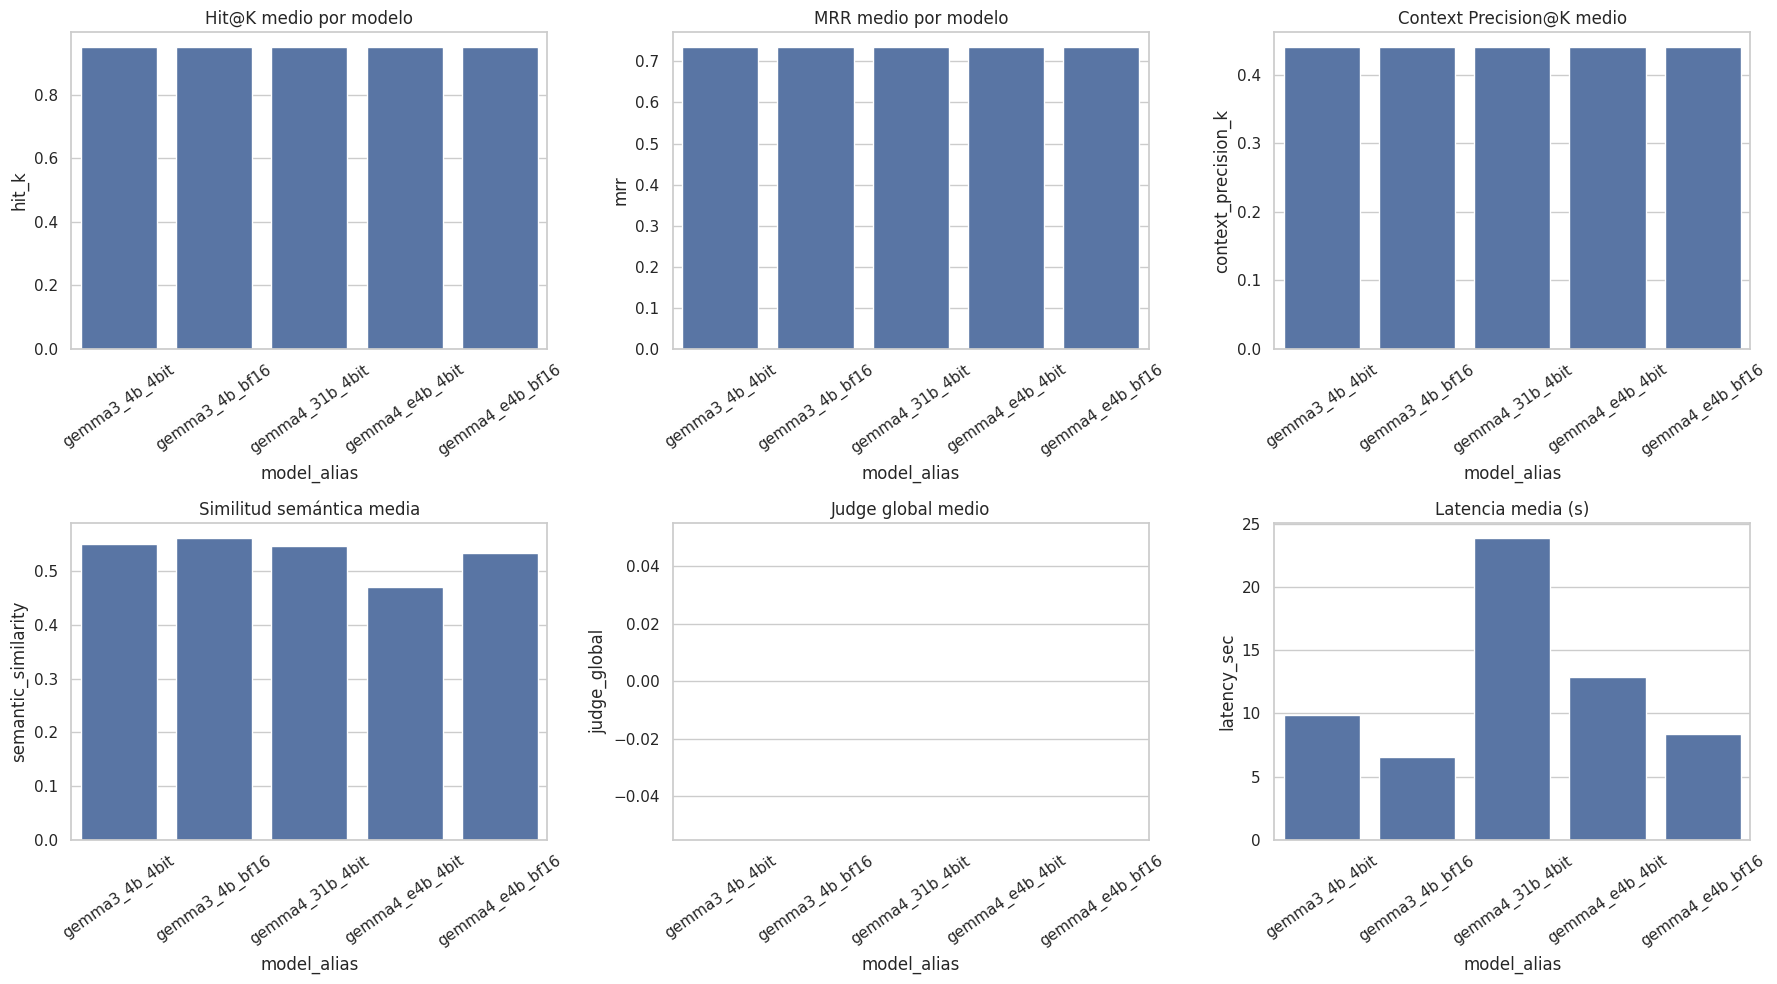

In [14]:
# GRÁFICAS PRINCIPALES (matplotlib/seaborn)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.barplot(data=agg, x='model_alias', y='hit_k', ax=axes[0,0])
axes[0,0].set_title('Hit@K medio por modelo')
axes[0,0].tick_params(axis='x', rotation=35)

sns.barplot(data=agg, x='model_alias', y='mrr', ax=axes[0,1])
axes[0,1].set_title('MRR medio por modelo')
axes[0,1].tick_params(axis='x', rotation=35)

sns.barplot(data=agg, x='model_alias', y='context_precision_k', ax=axes[0,2])
axes[0,2].set_title('Context Precision@K medio')
axes[0,2].tick_params(axis='x', rotation=35)

sns.barplot(data=agg, x='model_alias', y='semantic_similarity', ax=axes[1,0])
axes[1,0].set_title('Similitud semántica media')
axes[1,0].tick_params(axis='x', rotation=35)

sns.barplot(data=agg, x='model_alias', y='judge_global', ax=axes[1,1])
axes[1,1].set_title('Judge global medio')
axes[1,1].tick_params(axis='x', rotation=35)

sns.barplot(data=agg, x='model_alias', y='latency_sec', ax=axes[1,2])
axes[1,2].set_title('Latencia media (s)')
axes[1,2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


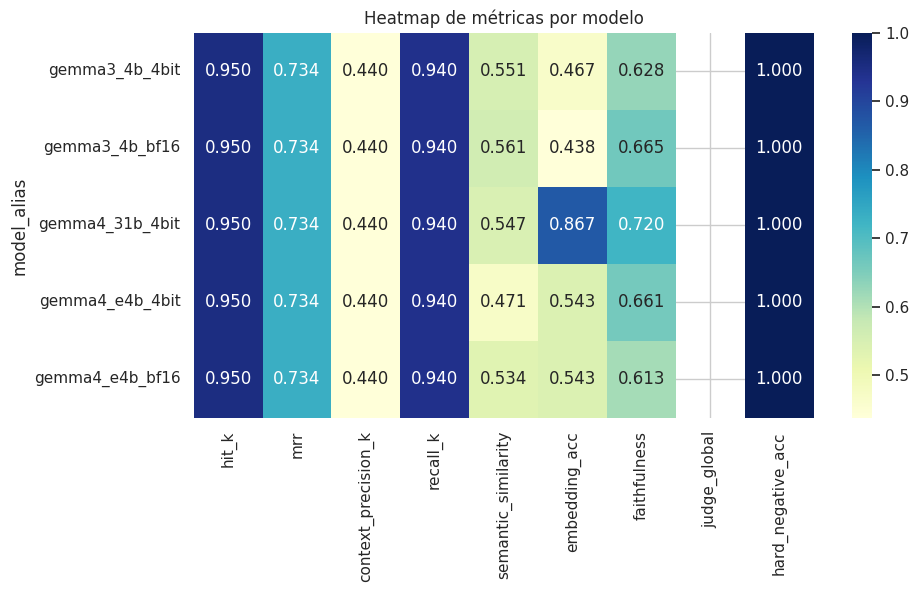

In [15]:
# MATRIZ DE CALOR DE MÉTRICAS NORMALIZADAS
metric_cols = ['hit_k','mrr','context_precision_k','recall_k','semantic_similarity','embedding_acc','faithfulness','judge_global','hard_negative_acc']
heat = agg.set_index('model_alias')[metric_cols]

plt.figure(figsize=(10,5))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('Heatmap de métricas por modelo')
plt.show()


In [23]:
# DASHBOARD INTERACTIVO (plotly): calidad vs coste
fig = px.scatter(
    agg,
    x='latency_sec',
    y='judge_global',
    size='hit_k',
    color='model_alias',
    hover_data=['mrr','context_precision_k','semantic_similarity','faithfulness','hard_negative_acc'],
    title='Trade-off calidad/coste (latencia vs judge_global)'
)
fig.show()


In [35]:
pd.set_option('display.max_columns', None)   # muestra todas las columnas
pd.set_option('display.width', None)         # evita saltos de línea raros
pd.set_option('display.max_colwidth', None)  # no corta contenido de columnas


# REGLAS DE FALLO (puedes ajustar umbrales arriba)
full['fail_retrieval'] = full['hit@k'].fillna(0) <= RETRIEVAL_FAIL_THRESHOLD
full['fail_semantic'] = full['semantic_similarity'].fillna(0) < SIM_FAIL_THRESHOLD
full['fail_faithfulness'] = full['faithfulness_score'].fillna(0) < FAITHFULNESS_FAIL_THRESHOLD
full['fail_judge'] = pd.to_numeric(full.get('judge_judge_global', np.nan), errors='coerce').fillna(0) < JUDGE_FAIL_THRESHOLD
full['fail_hard_negative'] = (full['abstention_expected'].fillna(0)==1) & (full['abstention_correct'].fillna(0)==0)

full['any_fail'] = full[['fail_retrieval','fail_semantic','fail_faithfulness','fail_judge','fail_hard_negative']].any(axis=1)

fail_counts = full.groupby('model_alias')[['fail_retrieval','fail_semantic','fail_faithfulness','fail_judge','fail_hard_negative','any_fail']].mean().reset_index()
display(fail_counts)


,model_alias,fail_retrieval,fail_semantic,fail_faithfulness,fail_judge,fail_hard_negative,any_fail
0,gemma3_4b_4bit,0.095238,0.390476,0.333333,1.0,0.0,1.0
1,gemma3_4b_bf16,0.095238,0.342857,0.295238,1.0,0.0,1.0
2,gemma4_31b_4bit,0.095238,0.171429,0.161905,1.0,0.0,1.0
3,gemma4_e4b_4bit,0.095238,0.476190,0.295238,1.0,0.0,1.0
4,gemma4_e4b_bf16,0.095238,0.400000,0.285714,1.0,0.0,1.0
